# Data Audit — Italian Architects' Buildings (Wikipedia Dataset)
**MBL549E Case Study 3 — Group B**

Merve Civcik · Hamdi Çakır · Şeyma Olcay

Aşağıdaki adımlar Case Study 2'de Wikipedia'dan kazınan veri seti üzerinde uygulanmıştır.

1. Veri Tutarlılığı Kontrolü
2. Eksik Veri Analizi
3. Outlier Analizi
4. Dağılım ve İstatistiksel Özet
5. Tekrarlayan Veri Kontrolü
6. Bias Kontrolü

## Modül İmportları

In [1]:
import pandas as pd
import numpy as np
from scipy.stats import skew, kurtosis
import matplotlib.pyplot as plt
import seaborn as sns

## Veri Yükleme

In [2]:
df = pd.read_pickle('/content/dataset.pkl')
df.head()

,url,title,country,building_type,coordinates,paragraphs,first_image_url,img_npy,architect,country_clean,country_normalized,country_top,building_type_clean,building_type_group
0,https://en.wikipedia.org/wiki/565_Broome_Street,565 Broome Street,U.S.,Residential Condominiums,40.72417°N 74.00556°W,[565 Broome Streetis a luxury residential buil...,https://upload.wikimedia.org/wikipedia/commons...,"[[[2, 0, 14], [1, 0, 13], [1, 0, 13], [0, 0, 1...",Renzo Piano,u.s.,united states,united states,residential condominiums,residential
1,https://en.wikipedia.org/wiki/Academy_Museum_o...,Academy Museum of Motion Pictures,U.S.,Motion picture history,34.06333°N 118.36083°W,[TheAcademy Museum of Motion Picturesis a film...,https://upload.wikimedia.org/wikipedia/en/thum...,"[[[186, 158, 94], [186, 158, 94], [186, 158, 9...",Renzo Piano,u.s.,united states,united states,motion picture history,other
2,https://en.wikipedia.org/wiki/Accademia_Nazion...,Accademia Nazionale di Santa Cecilia Musical I...,Rome,None,41.928931°N 12.474794°E,[TheAccademia Nazionale di Santa Cecilia Music...,None,None,Renzo Piano,rome,italy,italy,None,unknown
3,https://en.wikipedia.org/wiki/Aquarium_of_Genoa,Aquarium of Genoa,Italy,None,44.4102889°N 8.9265472°E,[TheAquarium of Genoa(Acquario di Genova) is t...,None,None,Renzo Piano,italy,italy,italy,None,unknown
4,https://en.wikipedia.org/wiki/Art_Institute_of...,Art Institute of Chicago Building,United States,None,41.8796°N 87.6237°W,[TheArt Institute of Chicago Building(initial ...,https://upload.wikimedia.org/wikipedia/commons...,"[[[255, 255, 255], [255, 255, 255], [255, 255,...",Renzo Piano,united states,united states,united states,None,unknown


In [22]:
df

,url,title,country,building_type,coordinates,paragraphs,first_image_url,img_npy,architect,country_clean,country_normalized,country_top,building_type_clean,building_type_group,paragraph_count,text_length,full_text
0,https://en.wikipedia.org/wiki/565_Broome_Street,565 Broome Street,U.S.,Residential Condominiums,40.72417°N 74.00556°W,[565 Broome Streetis a luxury residential buil...,https://upload.wikimedia.org/wikipedia/commons...,"[[[2, 0, 14], [1, 0, 13], [1, 0, 13], [0, 0, 1...",Renzo Piano,u.s.,united states,united states,residential condominiums,residential,5,2088,565 Broome Streetis a luxury residential build...
1,https://en.wikipedia.org/wiki/Academy_Museum_o...,Academy Museum of Motion Pictures,U.S.,Motion picture history,34.06333°N 118.36083°W,[TheAcademy Museum of Motion Picturesis a film...,https://upload.wikimedia.org/wikipedia/en/thum...,"[[[186, 158, 94], [186, 158, 94], [186, 158, 9...",Renzo Piano,u.s.,united states,united states,motion picture history,other,33,8528,TheAcademy Museum of Motion Picturesis a film ...
2,https://en.wikipedia.org/wiki/Accademia_Nazion...,Accademia Nazionale di Santa Cecilia Musical I...,Rome,None,41.928931°N 12.474794°E,[TheAccademia Nazionale di Santa Cecilia Music...,None,None,Renzo Piano,rome,italy,italy,None,unknown,9,1272,TheAccademia Nazionale di Santa Cecilia Musica...
3,https://en.wikipedia.org/wiki/Aquarium_of_Genoa,Aquarium of Genoa,Italy,None,44.4102889°N 8.9265472°E,[TheAquarium of Genoa(Acquario di Genova) is t...,None,None,Renzo Piano,italy,italy,italy,None,unknown,8,5719,TheAquarium of Genoa(Acquario di Genova) is th...
4,https://en.wikipedia.org/wiki/Art_Institute_of...,Art Institute of Chicago Building,United States,None,41.8796°N 87.6237°W,[TheArt Institute of Chicago Building(initial ...,https://upload.wikimedia.org/wikipedia/commons...,"[[[255, 255, 255], [255, 255, 255], [255, 255,...",Renzo Piano,united states,united states,united states,None,unknown,21,9012,TheArt Institute of Chicago Building(initial 1...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
206,https://en.wikipedia.org/wiki/Villa_Trissino_(...,Villa Trissino (Meledo di Sarego),Italy,None,45.42833°N 11.41361°E,[Villa Trissinois an incompletepatrician villa...,None,None,Andrea Palladio,italy,italy,italy,None,unknown,8,3337,Villa Trissinois an incompletepatrician villad...
207,https://en.wikipedia.org/wiki/Villa_Valmarana_...,Villa Valmarana (Lisiera),Italy,None,45.5798278°N 11.6102583°E,[TheVilla Valmarana(also known asValmarana Sca...,None,None,Andrea Palladio,italy,italy,italy,None,unknown,3,706,TheVilla Valmarana(also known asValmarana Scag...
208,https://en.wikipedia.org/wiki/Villa_Valmarana_...,Villa Valmarana (Vigardolo),None,None,45.6073611°N 11.58444°E,[45°36′26.50″N11°35′4″E﻿ / ﻿45.6073611°N 11.58...,None,None,Andrea Palladio,None,unknown,unknown,None,unknown,4,1017,45°36′26.50″N11°35′4″E﻿ / ﻿45.6073611°N 11.584...
209,https://en.wikipedia.org/wiki/Villa_Zeno,Villa Zeno,Italy,None,45.70028°N 12.64306°E,"[Villa Zenois a patricianvillaatCessalto,Venet...",None,None,Andrea Palladio,italy,italy,italy,None,unknown,4,1223,"Villa Zenois a patricianvillaatCessalto,Veneto..."


# 1. Numerik Değişkenler ve İstatistikleri ve Dağılım


Column: paragraph_count
Mean: 12.25
Median: 8.00
Mode: 5
Std: 13.32
Skewness: 3.40
Kurtosis: 14.48


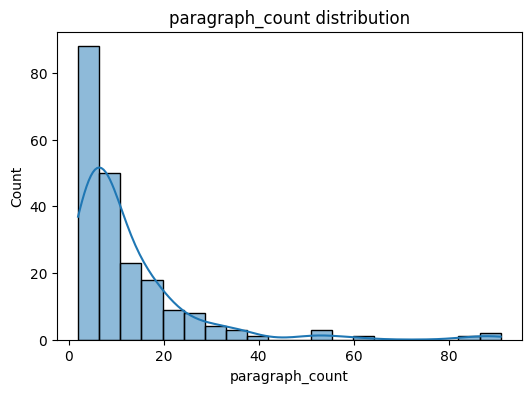


Column: text_length
Mean: 5303.34
Median: 2687.00
Mode: 2769
Std: 8067.59
Skewness: 4.37
Kurtosis: 23.12


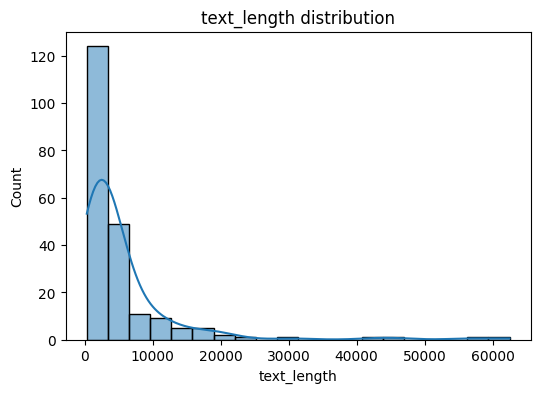

In [21]:
# Veri seti metin tabanlı olduğundan sayısal özellik türetiyoruz
df['paragraph_count'] = df['paragraphs'].apply(lambda x: len(x) if isinstance(x, list) else 0)
df['text_length'] = df['paragraphs'].apply(
    lambda x: sum(len(p) for p in x) if isinstance(x, list) else 0
)
num_cols = df.select_dtypes(include=[np.number]).columns
for col in num_cols:
    col_data = df[col].dropna()
    print(f"\nColumn: {col}")
    #.2f notasyonu float bir değerde decimal point sonrasındaki sadece 2 değerin yazılacağını gösterir)
    print(f"Mean: {col_data.mean():.2f}")
    print(f"Median: {col_data.median():.2f}")
    print(f"Mode: {col_data.mode()[0]}")
    print(f"Std: {col_data.std():.2f}")
    print(f"Skewness: {skew(col_data):.2f}")
    print(f"Kurtosis: {kurtosis(col_data):.2f}")

    # Histogram ve density plot
    plt.figure(figsize=(6,4))
    sns.histplot(col_data, kde=True, bins=20)
    plt.title(f"{col} distribution")
    plt.savefig(f'distribution_numeric.png', dpi=150)
    plt.show()

# 2. Outlier Analizi (IQR Yöntemi)

In [4]:
# IQR yöntemi ile outlier tespiti
num_cols = ['paragraph_count', 'text_length']


for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)][col]
    print(f"{col} outliers:\n{outliers.values}\n")

paragraph_count outliers:
[33 54 31 33 51 38 85 88 60 33 34 35 37 91 52]

text_length outliers:
[13938 20586 12700 13677 15718 14718 20051 22769 42673 62497 46061 18053
 18443 16486 56561 12675 30625 18828 18203 12864]



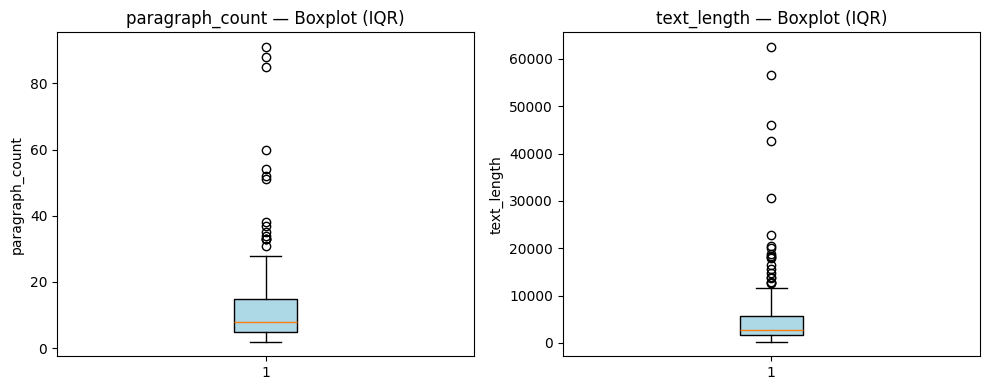

In [5]:
# Outlier görselleştirme (boxplot)
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for i, col in enumerate(num_cols):
    axes[i].boxplot(df[col], vert=True, patch_artist=True,
                    boxprops=dict(facecolor='lightblue'))
    axes[i].set_title(f'{col} — Boxplot (IQR)')
    axes[i].set_ylabel(col)
plt.tight_layout()
plt.savefig('outlier_boxplot.png', dpi=150)
plt.show()

# 3. Eksik Veri Analizi

## 3.1 Eksik Veri Kontrolü

In [6]:
missing_counts = df.isna().sum()
print(missing_counts)

url                      0
title                    0
country                 71
building_type          150
coordinates              8
paragraphs               0
first_image_url        134
img_npy                134
architect                0
country_clean           71
country_normalized       0
country_top              0
building_type_clean    150
building_type_group      0
paragraph_count          0
text_length              0
dtype: int64


In [7]:
# Sütun bazında eksik veri sayısı ve oranı
missing_counts = df.isna().sum()
missing_pct = (missing_counts / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Eksik Sayı': missing_counts, 'Eksik %': missing_pct})
print(missing_df[missing_df['Eksik Sayı'] > 0].sort_values('Eksik %', ascending=False))

                     Eksik Sayı  Eksik %
building_type               150    71.09
building_type_clean         150    71.09
first_image_url             134    63.51
img_npy                     134    63.51
country                      71    33.65
country_clean                71    33.65
coordinates                   8     3.79


## 3.2 Eksik Veri Görselleştirme

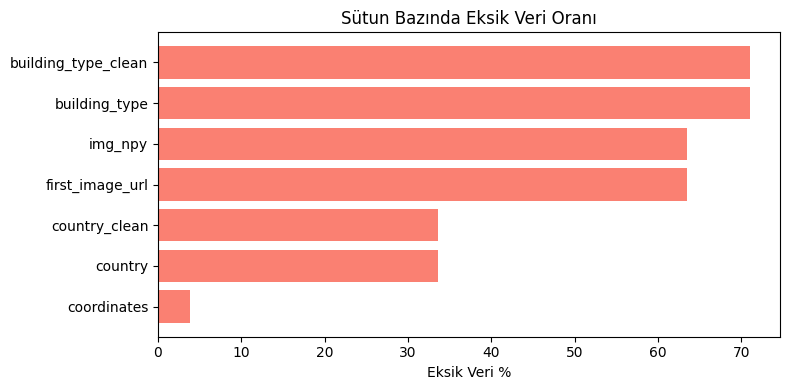

In [8]:
# Eksik veri oranlarını görselleştiriyoruz
missing_plot = missing_df[missing_df['Eksik Sayı'] > 0].sort_values('Eksik %')
plt.figure(figsize=(8, 4))
plt.barh(missing_plot.index, missing_plot['Eksik %'], color='salmon')
plt.xlabel('Eksik Veri %')
plt.title('Sütun Bazında Eksik Veri Oranı')
plt.tight_layout()
plt.savefig('missing_data.png', dpi=150)
plt.show()

In [9]:
# Eksik veri tipi analizi (MCAR, MAR, MNAR)
#
# building_type (%71.1) -> MNAR (Missing Not At Random)
#   Wikipedia bilgi kutusunda bina tipi alanı genellikle doldurulmamaktadır.
#   Eksiklik, yapının belgesiyle doğrudan ilişkilidir.
#
# country (%33.6) -> MAR (Missing At Random)
#   Ülke bilgisi sayfa yapısına bağlı olarak ayrıştırılamamıştır.
#   Eksiklik ülkenin kendisine değil, sayfa formatına bağlıdır.
#
# coordinates (%3.8) -> MCAR (Missing Completely At Random)
#   Küçük ve rastgele bir alt kümede koordinat bulunmamaktadır.

print("Eksik veri tipi analizi tamamlandi.")
print("building_type  -> MNAR")
print("country        -> MAR")
print("coordinates    -> MCAR")

Eksik veri tipi analizi tamamlandi.
building_type  -> MNAR
country        -> MAR
coordinates    -> MCAR


# 4. Eksik Verilerin Doldurulması

In [10]:
# Kayıp veriler doldurulacağı için öncelikle orjinal verinin kopyası oluşturuluyor.
df_fill = df.copy()
#her bir kolon için kayıp değerleri doldurmak için for loop kullanılıyor
for col in df_fill.columns:
    #eğer değerler float64 veya integer64 veri tipindeyse kolonlardaki boş değerler median değeri ile dolduruluyor. Inplace= True df_fill dataframeinin kendisinde değişiklik yapıyor.
    if df_fill[col].dtype in [np.float64, np.int64]:
        df_fill[col].fillna(df_fill[col].median(), inplace=True)
    #eğer kolon değerleri numeric değilse kayıp değerler "Missing" yazılarak string ile dolduruluyor
    elif df_fill[col].dtype == object:
        df_fill[col].fillna("Missing", inplace=True)

print(df_fill.head())

/tmp/ipykernel_17007/1404012024.py:10: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_fill[col].fillna("Missing", inplace=True)
/tmp/ipykernel_17007/1404012024.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try u

                                                 url  \
0    https://en.wikipedia.org/wiki/565_Broome_Street   
1  https://en.wikipedia.org/wiki/Academy_Museum_o...   
2  https://en.wikipedia.org/wiki/Accademia_Nazion...   
3    https://en.wikipedia.org/wiki/Aquarium_of_Genoa   
4  https://en.wikipedia.org/wiki/Art_Institute_of...   

                                               title        country  \
0                                  565 Broome Street           U.S.   
1                  Academy Museum of Motion Pictures           U.S.   
2  Accademia Nazionale di Santa Cecilia Musical I...           Rome   
3                                  Aquarium of Genoa          Italy   
4                  Art Institute of Chicago Building  United States   

              building_type               coordinates  \
0  Residential Condominiums     40.72417°N 74.00556°W   
1    Motion picture history    34.06333°N 118.36083°W   
2                   Missing   41.928931°N 12.474794°E   
3       

## 4.1. Veri Tutarlılığı Kontrolü

In [11]:
# Her bir kolondaki veri tiplerini kontrol ediyoruz
print(df_fill.dtypes)

url                    object
title                  object
country                object
building_type          object
coordinates            object
paragraphs             object
first_image_url        object
img_npy                object
architect              object
country_clean          object
country_normalized     object
country_top            object
building_type_clean    object
building_type_group    object
paragraph_count         int64
text_length             int64
dtype: object


In [12]:
# Her bir kolondaki eşsiz veri tiplerini listeliyoruz
# Bir kolonda birden fazla tip varsa veri uyuşmazlığı var demektir
for col in df_fill.columns:
    types = df_fill[col].apply(lambda x: type(x)).unique()
    print(f"{col} tipleri: {types}")

url tipleri: [<class 'str'>]
title tipleri: [<class 'str'>]
country tipleri: [<class 'str'>]
building_type tipleri: [<class 'str'>]
coordinates tipleri: [<class 'str'>]
paragraphs tipleri: [<class 'list'>]
first_image_url tipleri: [<class 'str'>]
img_npy tipleri: [<class 'numpy.ndarray'> <class 'str'>]
architect tipleri: [<class 'str'>]
country_clean tipleri: [<class 'str'>]
country_normalized tipleri: [<class 'str'>]
country_top tipleri: [<class 'str'>]
building_type_clean tipleri: [<class 'str'>]
building_type_group tipleri: [<class 'str'>]
paragraph_count tipleri: [<class 'int'>]
text_length tipleri: [<class 'int'>]


# 5. Kategorik değişken kontrolü


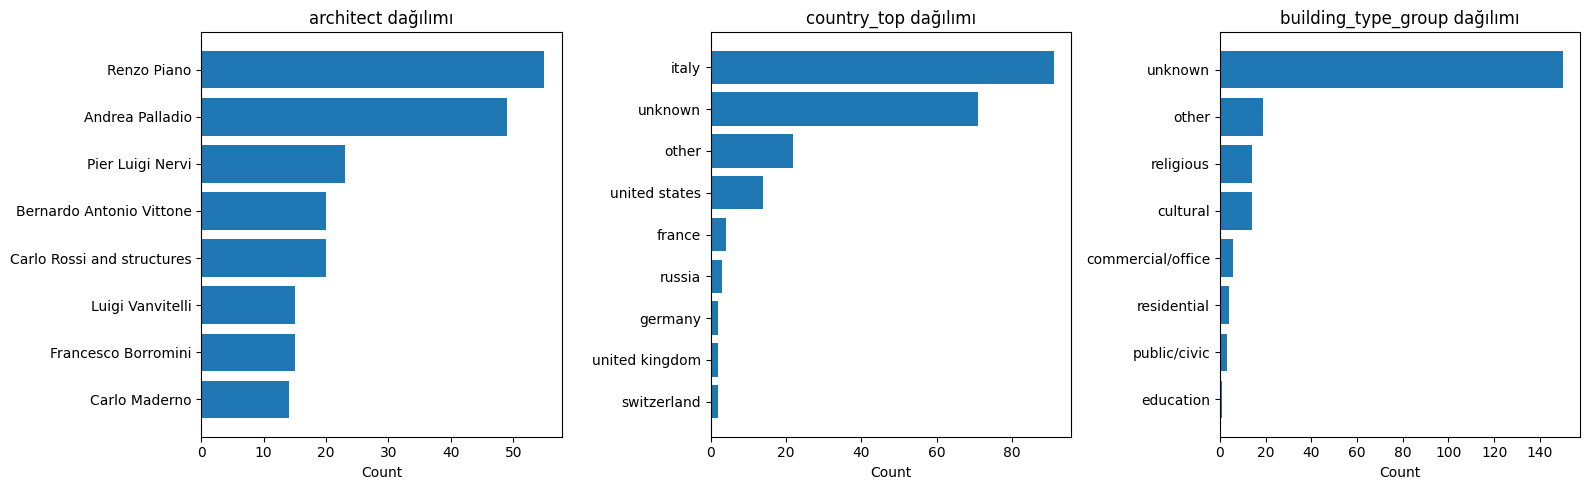

In [13]:
# Kategorik değişkenler için frekans dağılımı
cat_plot_cols = ['architect', 'country_top', 'building_type_group']
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, col in zip(axes, cat_plot_cols):
    counts = df[col].value_counts()
    ax.barh(counts.index[::-1], counts.values[::-1])
    ax.set_title(f'{col} dağılımı')
    ax.set_xlabel('Count')
plt.tight_layout()
plt.savefig('distribution_categorical.png', dpi=150)
plt.show()

## 5.1 Tekrarlayan Veri Kontrolü

In [14]:
# img_npy ve paragraphs sütunları hashlenemediğinden metin sütunları kullanılıyor
text_cols = ['url', 'title', 'country', 'building_type', 'coordinates',
             'first_image_url', 'architect',
             'country_normalized', 'country_top', 'building_type_group']

duplicates = df[text_cols].duplicated()
print(f"Duplicate satırlar: \n{df[text_cols][duplicates]}")

url_dupes = df.duplicated(subset=['url'])
print(f"\nDuplicate URL sayısı: {url_dupes.sum()}")

title_dupes = df.duplicated(subset=['title'])
print(f"Duplicate başlık sayısı: {title_dupes.sum()}")

Duplicate satırlar: 
Empty DataFrame
Columns: [url, title, country, building_type, coordinates, first_image_url, architect, country_normalized, country_top, building_type_group]
Index: []

Duplicate URL sayısı: 3
Duplicate başlık sayısı: 3


## 5.2 Bias Kontrolü

In [15]:
# Kategorik grupların dağılım dengesi kontrol ediliyor
# Belli gruplar daha az temsil ediliyor mu?
for col in ['architect', 'country_top', 'building_type_group']:
    counts = df[col].value_counts()
    print(f"\n{col} dağılımı:\n{counts}")
    print(f"{col} yüzdelik dağılım:\n{(counts/counts.sum()*100).round(2)}")


architect dağılımı:
architect
Renzo Piano                   55
Andrea Palladio               49
Pier Luigi Nervi              23
Bernardo Antonio Vittone      20
Carlo Rossi and structures    20
Luigi Vanvitelli              15
Francesco Borromini           15
Carlo Maderno                 14
Name: count, dtype: int64
architect yüzdelik dağılım:
architect
Renzo Piano                   26.07
Andrea Palladio               23.22
Pier Luigi Nervi              10.90
Bernardo Antonio Vittone       9.48
Carlo Rossi and structures     9.48
Luigi Vanvitelli               7.11
Francesco Borromini            7.11
Carlo Maderno                  6.64
Name: count, dtype: float64

country_top dağılımı:
country_top
italy             91
unknown           71
other             22
united states     14
france             4
russia             3
germany            2
united kingdom     2
switzerland        2
Name: count, dtype: int64
country_top yüzdelik dağılım:
country_top
italy             43.13
unknown  

In [16]:
# Kategorik sütunlardaki eşsiz değerleri listeliyoruz
# Beklenmedik ya da yanlış kategori var mı kontrol ediyoruz
cat_cols = ['architect', 'country_normalized', 'country_top', 'building_type_group']
for col in cat_cols:
    print(f"{col}: {df[col].unique()}")

architect: ['Renzo Piano' 'Carlo Maderno' 'Luigi Vanvitelli' 'Francesco Borromini'
 'Carlo Rossi and structures' 'Bernardo Antonio Vittone'
 'Pier Luigi Nervi' 'Andrea Palladio']
country_normalized: ['united states' 'italy' 'unknown' 'germany' 'australia' 'switzerland'
 'united kingdom' 'france' 'malta' 'taiwan' 'new caledonia' 'japan'
 'netherlands' 'flaminio' 'it' 'portugal.' '28' 'russia' 'poland'
 'tallinn' '94109' 'south africa [ 1 ]' 'piedmont' 'pantelleria' 'liguria'
 'nh' 'canada']
country_top: ['united states' 'italy' 'unknown' 'germany' 'other' 'switzerland'
 'united kingdom' 'france' 'russia']
building_type_group: ['residential' 'other' 'unknown' 'commercial/office' 'cultural'
 'public/civic' 'religious' 'education']


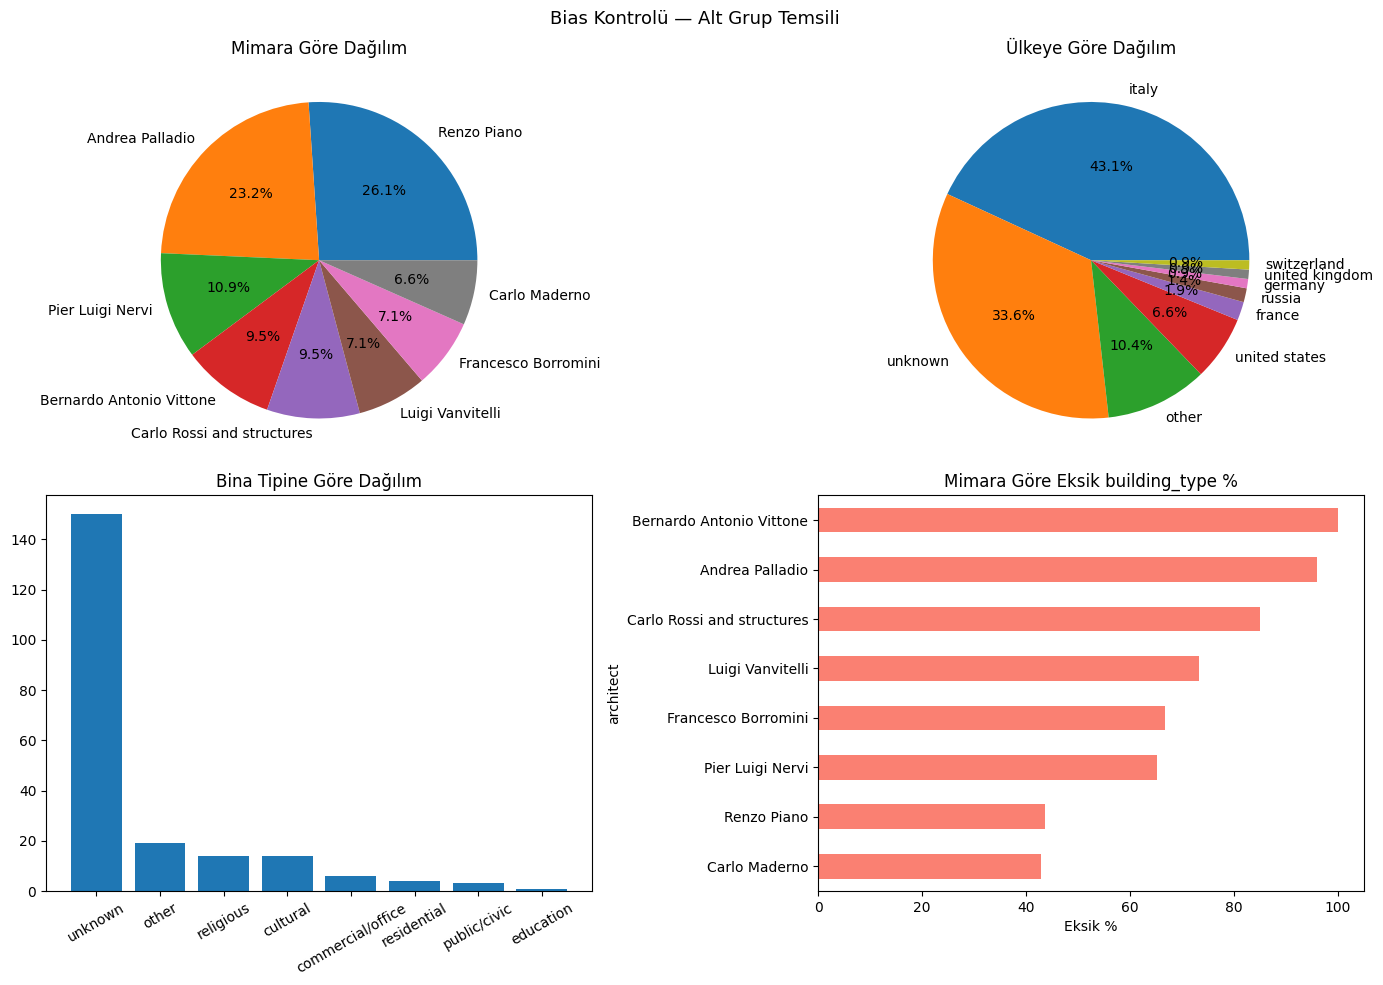

In [17]:
# Bias görselleştirme
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Mimar dağılımı
arch_counts = df['architect'].value_counts()
axes[0,0].pie(arch_counts.values, labels=arch_counts.index, autopct='%1.1f%%')
axes[0,0].set_title('Mimara Göre Dağılım')

# Ülke dağılımı
country_counts = df['country_top'].value_counts()
axes[0,1].pie(country_counts.values, labels=country_counts.index, autopct='%1.1f%%')
axes[0,1].set_title('Ülkeye Göre Dağılım')

# Bina tipi dağılımı
btype_counts = df['building_type_group'].value_counts()
axes[1,0].bar(btype_counts.index, btype_counts.values)
axes[1,0].set_title('Bina Tipine Göre Dağılım')
axes[1,0].tick_params(axis='x', rotation=30)

# Mimara göre eksik building_type oranı
missing_by_arch = df.groupby('architect')['building_type'].apply(
    lambda x: x.isnull().sum() / len(x) * 100
)
missing_by_arch.sort_values().plot(kind='barh', ax=axes[1,1], color='salmon')
axes[1,1].set_title('Mimara Göre Eksik building_type %')
axes[1,1].set_xlabel('Eksik %')

plt.suptitle('Bias Kontrolü — Alt Grup Temsili', fontsize=13)
plt.tight_layout()
plt.savefig('bias_check.png', dpi=150)
plt.show()

# 6 Semantik Outlier Bulma

In [18]:
import numpy as np
import pandas as pd
from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_distances

# Örnek text verisini import et
newsgroups = fetch_20newsgroups(subset='train', remove=('headers', 'footers', 'quotes'))
texts = newsgroups.data

In [19]:
# 'paragraphs' sütunundaki liste elemanlarını birleştirerek tek bir metin sütunu oluşturun
df['full_text'] = df['paragraphs'].apply(lambda x: ' '.join(x) if isinstance(x, list) else '')

# TF-IDF vektörleştiriciyi tanımlayın
vectorizer_df = TfidfVectorizer(stop_words='english', max_features=1000)

# Metin verilerini vektörleştirin
X_df = vectorizer_df.fit_transform(df['full_text'])

# Vektörler arasındaki kosinüs mesafelerini hesaplayın
dist_matrix_df = cosine_distances(X_df)

# Her bir metnin diğerlerine olan ortalama mesafesini hesaplayın
avg_dist_df = dist_matrix_df.mean(axis=1)

# Aykırı değer eşiğini belirleyin (örn: en uzak %10)
threshold_df = np.percentile(avg_dist_df, 90)

# Eşik değerinden büyük olanları anlamsal aykırı değer olarak belirleyin
semantic_outliers_df = df.iloc[np.where(avg_dist_df > threshold_df)[0]]

print("Kendi veri setinizdeki anlamsal aykırı değerlerin ilk 5'i:")
semantic_outliers_df[['title', 'full_text']].head()

Kendi veri setinizdeki anlamsal aykırı değerlerin ilk 5'i:


,title,full_text
11,Brignole (Genoa Metro),Brignoleis a metro station on the line 1 at Ge...
17,City Gate (Valletta),"City Gate(Maltese:Bieb il-Belt, literally ""Doo..."
21,Exelon Pavilions,TheExelon Pavilionsare four buildings that gen...
28,IRCAM,IRCAM(French:Institut de recherche et coordina...
30,Kansai International Airport,"Kansai International Airport(Japanese:関西国際空港,r..."


## 6.1 Semantik Outlier'ı Export et

In [20]:
# DataFrame'i CSV dosyasına kaydetme
# index=False parametresi ile indeks sütununun dosyaya yazılmasını engelleriz.
semantic_outliers_df.to_csv('semantic_outliers.csv', index=False)
print("semantic_outliers_df başarıyla 'semantic_outliers.csv' olarak kaydedildi.")

semantic_outliers_df başarıyla 'semantic_outliers.csv' olarak kaydedildi.
